# Setup

In [1]:
# Reference notebook for the canonical `rl_signaling` API.
#
# Each section below runs a small simulation with one of the three agent
# types (`UrnAgent`, `QLearningAgent`, `TDLearningAgent`) on the canonical
# 2-feature / 4-action signaling game, with a 2-agent fully-connected
# graph. Identical scaffolding across all three sections — only the
# `agent_type=` argument changes — demonstrates the unified API.

import sys
import os

sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..")))

import networkx as nx

from rl_signaling import (
    MultiAgentEnv,
    QLearningAgent,
    TDLearningAgent,
    UrnAgent,
    run_simulation,
)
from rl_signaling.games import create_random_canonical_game


# Shared scaffolding across the three sections below.
N_AGENTS = 2
N_FEATURES = 2
N_SIGNALING_ACTIONS = 2
N_FINAL_ACTIONS = 4
OBSERVED_VARIABLES = {0: [0], 1: [1]}

graph = nx.DiGraph()
graph.add_nodes_from([0, 1])
graph.add_edges_from([(0, 1), (1, 0)])

game_dicts = {
    i: create_random_canonical_game(N_FEATURES, N_FINAL_ACTIONS)
    for i in range(N_AGENTS)
}


# Urn Agent

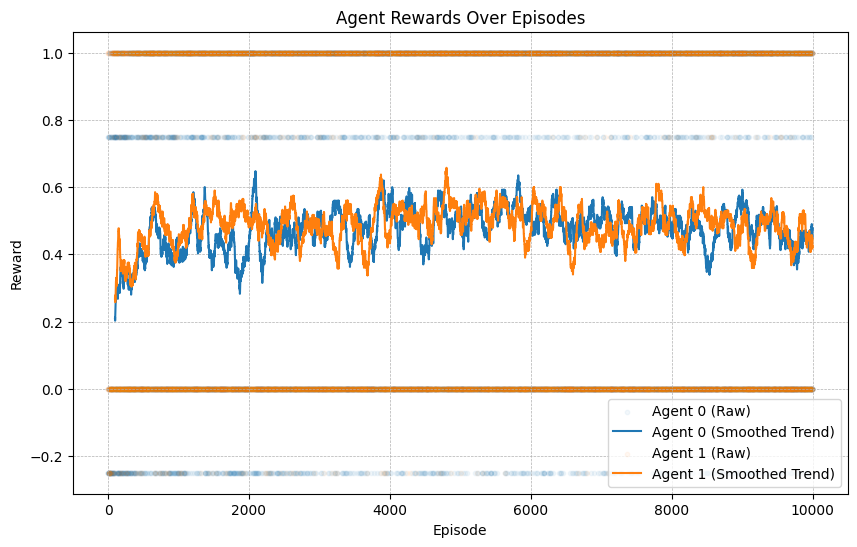

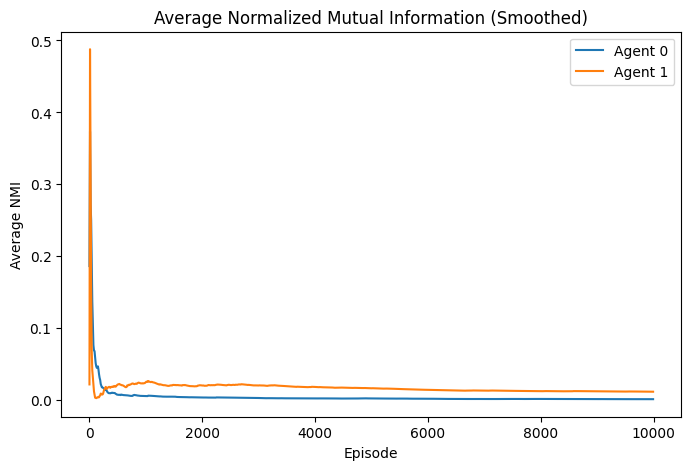

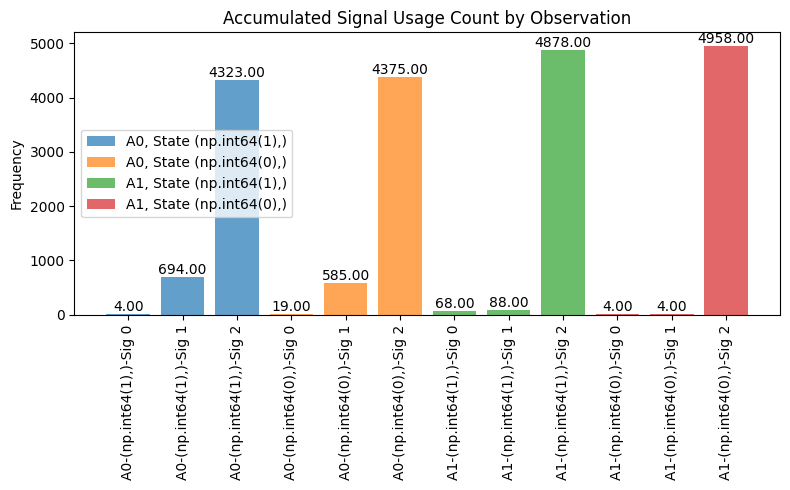

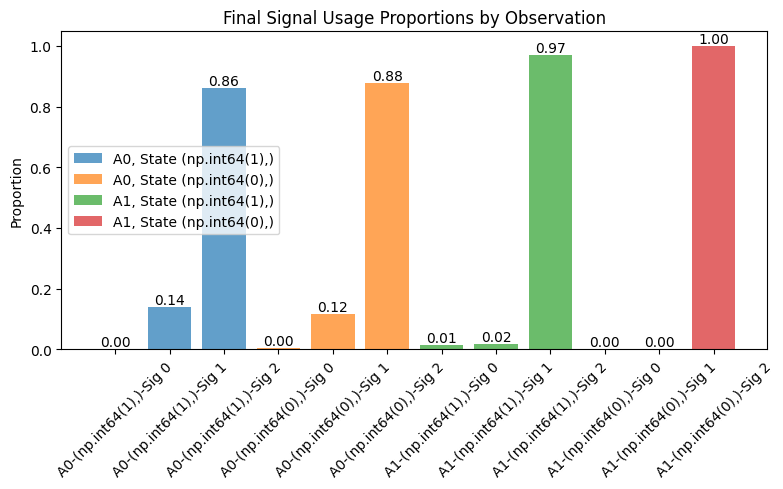

([{(np.int64(1),): array([4.000e+00, 6.940e+02, 4.323e+03]),
   (np.int64(0),): array([  19.,  585., 4375.])},
  {(np.int64(1),): array([  68.,   88., 4878.]),
   (np.int64(0),): array([4.000e+00, 4.000e+00, 4.958e+03])}],
 [[-0.25,
   0.75,
   -0.25,
   -0.25,
   0,
   -0.25,
   0.75,
   -0.25,
   0,
   -0.25,
   -0.25,
   0.75,
   0,
   -0.25,
   -0.25,
   -0.25,
   0.75,
   -0.25,
   0.75,
   0,
   0.75,
   0.75,
   -0.25,
   -0.25,
   -0.25,
   -0.25,
   1,
   -0.25,
   0,
   -0.25,
   0.75,
   -0.25,
   1,
   1,
   1,
   0,
   -0.25,
   -0.25,
   0.75,
   0.75,
   -0.25,
   -0.25,
   0,
   0.75,
   -0.25,
   -0.25,
   0,
   0,
   1,
   0,
   1,
   -0.25,
   0,
   -0.25,
   0,
   0,
   0.75,
   1,
   0,
   0,
   0.75,
   -0.25,
   0.75,
   -0.25,
   0.75,
   1,
   1,
   -0.25,
   -0.25,
   0,
   0,
   -0.25,
   -0.25,
   -0.25,
   0,
   -0.25,
   0,
   0,
   0.75,
   -0.25,
   0.75,
   0.75,
   -0.25,
   0,
   -0.25,
   -0.25,
   -0.25,
   0.75,
   0.75,
   0,
   0.75,
   1,
   0.7

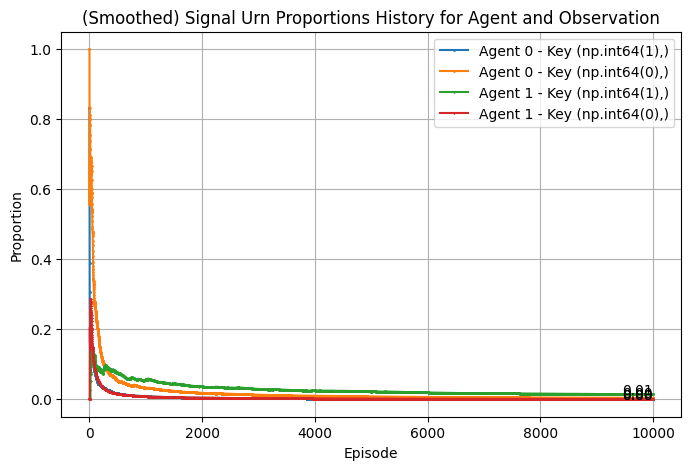

In [2]:
env = MultiAgentEnv(
    n_agents=N_AGENTS,
    n_features=N_FEATURES,
    n_signaling_actions=N_SIGNALING_ACTIONS,
    n_final_actions=N_FINAL_ACTIONS,
    full_information=False,
    game_dicts=game_dicts,
    observed_variables=OBSERVED_VARIABLES,
    agent_type=UrnAgent,
    costly_signaling=True,
    graph=graph,
)

run_simulation(
    env,
    n_episodes=10000,
    with_signals=True,
    signal_cost=[0.25, 0.25],
    plot=True,
)


# QLearning Agent

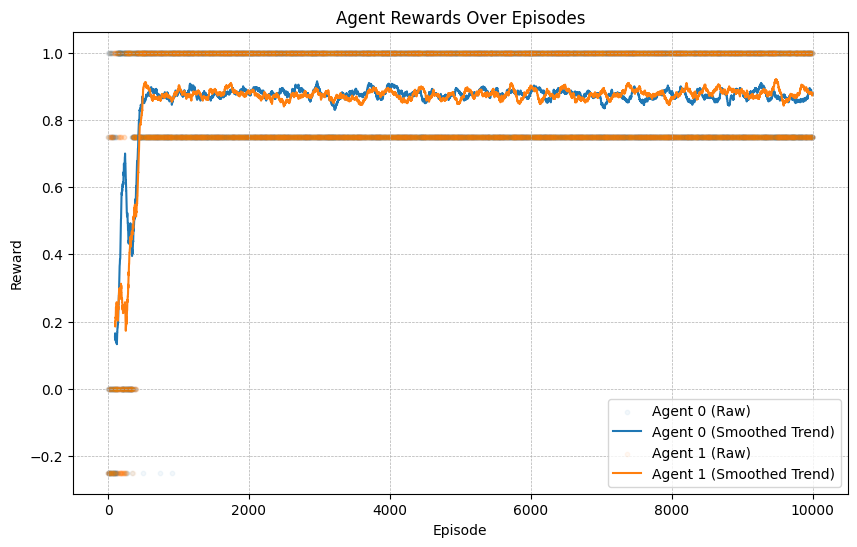

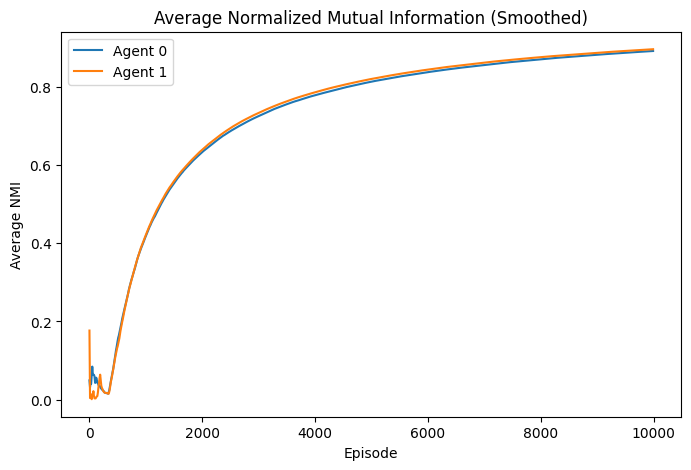

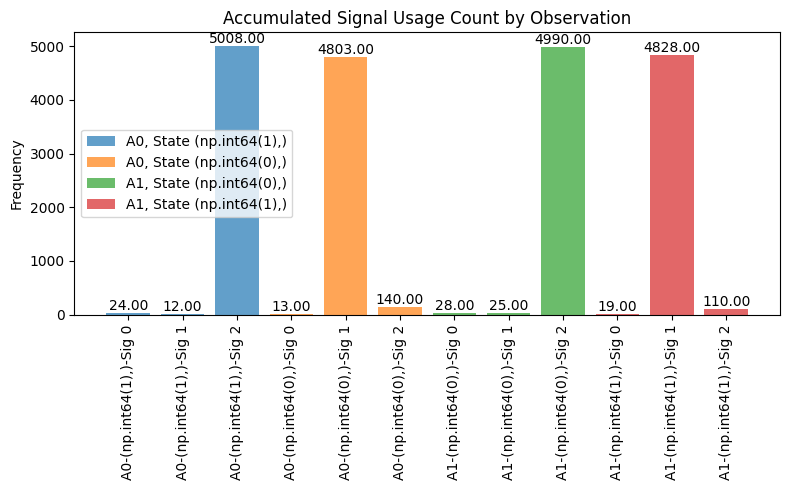

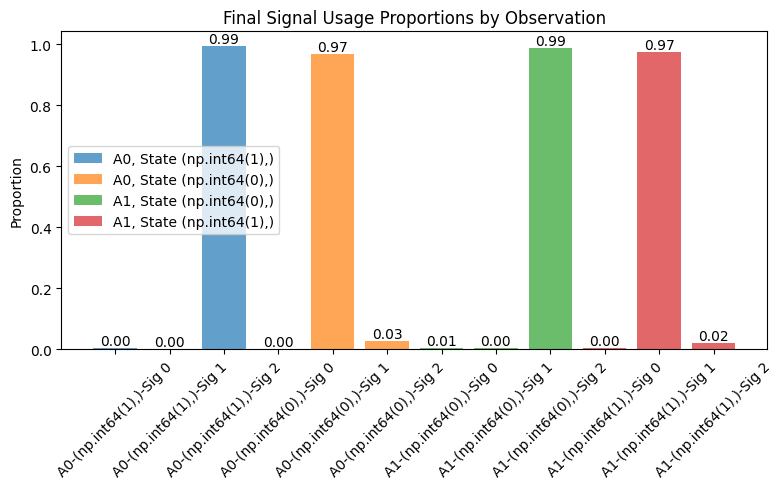

([{(np.int64(1),): array([  24.,   12., 5008.]),
   (np.int64(0),): array([  13., 4803.,  140.])},
  {(np.int64(0),): array([  28.,   25., 4990.]),
   (np.int64(1),): array([  19., 4828.,  110.])}],
 [[-0.25,
   -0.25,
   0.75,
   -0.25,
   0,
   1,
   0,
   0.75,
   -0.25,
   0,
   -0.25,
   -0.25,
   -0.25,
   1,
   1,
   0,
   1,
   0,
   -0.25,
   -0.25,
   0,
   -0.25,
   -0.25,
   0.75,
   1,
   1,
   0,
   0,
   -0.25,
   1,
   0,
   -0.25,
   0,
   -0.25,
   0,
   -0.25,
   0,
   0,
   0.75,
   -0.25,
   0.75,
   -0.25,
   0.75,
   1,
   -0.25,
   0,
   -0.25,
   -0.25,
   0,
   1,
   1,
   0.75,
   -0.25,
   1,
   0,
   1,
   0,
   0,
   -0.25,
   0,
   0.75,
   0,
   0,
   -0.25,
   1,
   0,
   0.75,
   0.75,
   0.75,
   0,
   0.75,
   0,
   0,
   0.75,
   -0.25,
   -0.25,
   -0.25,
   -0.25,
   -0.25,
   0,
   -0.25,
   0,
   -0.25,
   0,
   0,
   0,
   -0.25,
   -0.25,
   0,
   0,
   -0.25,
   0.75,
   -0.25,
   0.75,
   -0.25,
   -0.25,
   0,
   0.75,
   -0.25,
   -0.25,
 

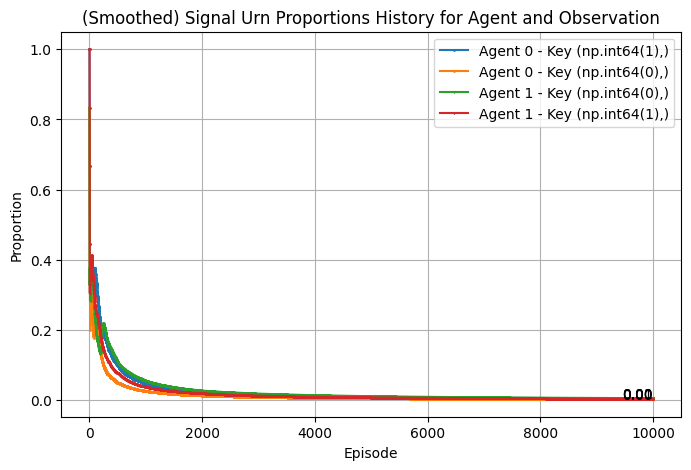

In [3]:
env = MultiAgentEnv(
    n_agents=N_AGENTS,
    n_features=N_FEATURES,
    n_signaling_actions=N_SIGNALING_ACTIONS,
    n_final_actions=N_FINAL_ACTIONS,
    full_information=False,
    game_dicts=game_dicts,
    observed_variables=OBSERVED_VARIABLES,
    agent_type=QLearningAgent,
    agent_kwargs={
        "exploration_rate": 0.9652628633727897,
        "exploration_decay": 0.9998122815486062,
        "min_exploration_rate": 1e-10,
        "choice": "ucb",
        "exp_smoothing": False,
    },
    costly_signaling=True,
    graph=graph,
)

run_simulation(
    env,
    n_episodes=10000,
    with_signals=True,
    signal_cost=[0.25, 0.25],
    plot=True,
)


# Temporal Difference Example

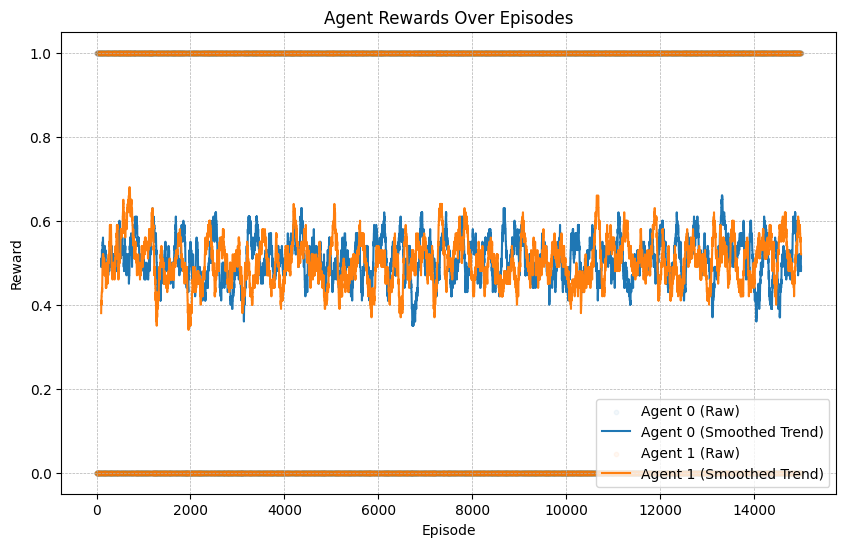

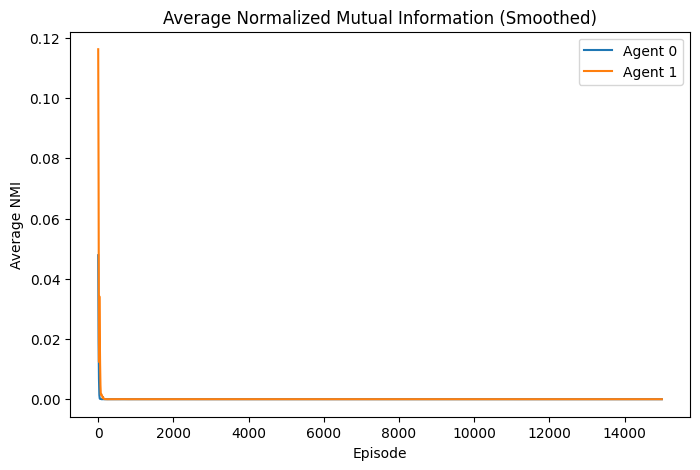

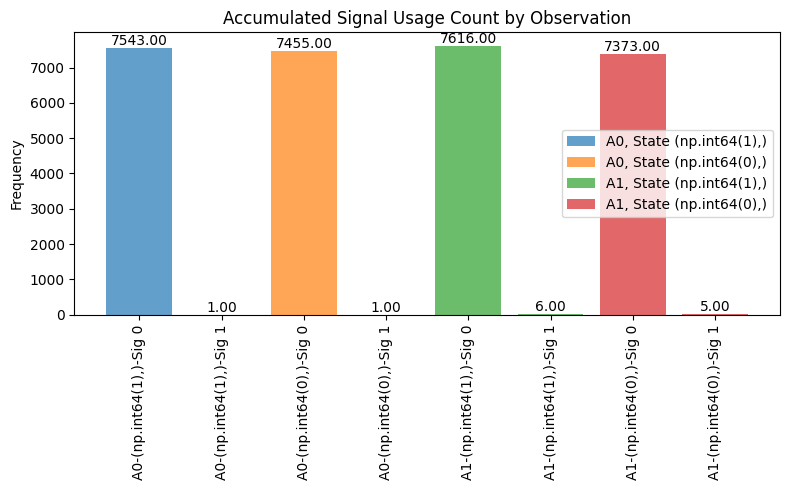

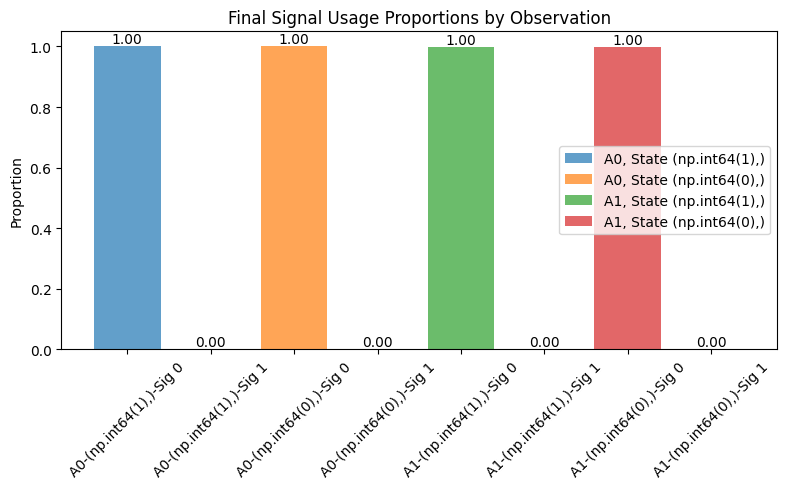

([{(np.int64(1),): array([7.543e+03, 1.000e+00]),
   (np.int64(0),): array([7.455e+03, 1.000e+00])},
  {(np.int64(1),): array([7.616e+03, 6.000e+00]),
   (np.int64(0),): array([7.373e+03, 5.000e+00])}],
 [[0,
   1,
   1,
   0,
   1,
   0,
   0,
   1,
   0,
   0,
   0,
   1,
   0,
   1,
   0,
   1,
   0,
   1,
   0,
   0,
   1,
   0,
   0,
   0,
   0,
   0,
   0,
   0,
   1,
   1,
   1,
   1,
   1,
   0,
   1,
   1,
   0,
   0,
   0,
   1,
   1,
   1,
   1,
   1,
   0,
   0,
   1,
   1,
   1,
   0,
   1,
   0,
   1,
   1,
   1,
   0,
   0,
   0,
   0,
   0,
   1,
   0,
   1,
   0,
   0,
   0,
   0,
   0,
   1,
   0,
   0,
   1,
   1,
   1,
   0,
   0,
   1,
   1,
   0,
   1,
   1,
   0,
   1,
   1,
   1,
   0,
   1,
   0,
   1,
   0,
   1,
   0,
   1,
   1,
   1,
   1,
   0,
   1,
   1,
   0,
   1,
   1,
   0,
   0,
   0,
   1,
   0,
   0,
   1,
   0,
   1,
   1,
   0,
   1,
   1,
   1,
   1,
   0,
   0,
   0,
   0,
   1,
   1,
   0,
   0,
   0,
   0,
   1,
   1,
   1,
   1,
   1,
   1,

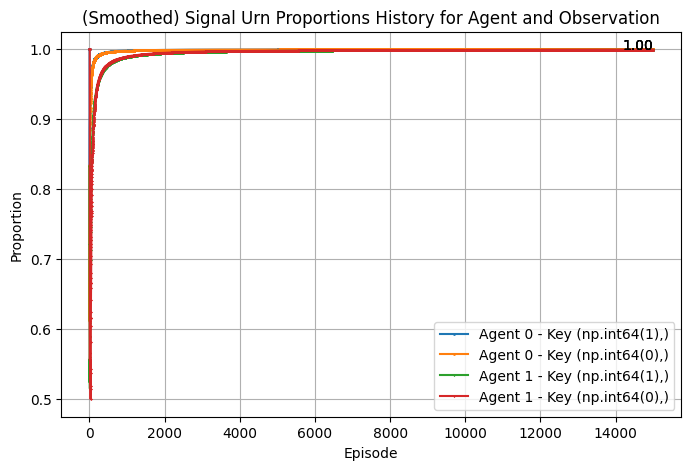

In [4]:
env = MultiAgentEnv(
    n_agents=N_AGENTS,
    n_features=N_FEATURES,
    n_signaling_actions=N_SIGNALING_ACTIONS,
    n_final_actions=N_FINAL_ACTIONS,
    full_information=False,
    game_dicts=game_dicts,
    observed_variables=OBSERVED_VARIABLES,
    agent_type=TDLearningAgent,
    agent_kwargs={
        "exploration_rate": 0.1,
        "exploration_decay": 0.9999999,
        "min_exploration_rate": 1e-10,
        "gamma": 0.9999999,
        "choice": "ucb",
    },
    graph=graph,
)

run_simulation(env, n_episodes=15000, with_signals=True, plot=True)
